# Day 2 · Notebook 3 — Predicting house prices (regression)
### ML Bootcamp · Day 2 of 5

**Question:** can we predict the median house value in a California district from facts about that district?

This is **regression**: the answer is a number. The data comes from the 1990 US census: **20,640 districts**, each with location, house age, rooms, population, income and distance to the ocean.

In this notebook you will:
1. Explore the data and find the most useful features
2. Clean it and engineer new features
3. Train **linear regression**, from one feature to all of them
4. Measure it with **MAE, RMSE and R²** — against a baseline

> Run the cells in order with **Shift + Enter**. 🧠 = think about it, ✍️ = exercise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
housing = pd.read_csv(url)
print(housing.shape)
housing.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Columns:** `median_income` is in **tens of thousands of dollars** (3.5 = $35,000). `median_house_value` (our **label**) is in dollars. Room, bedroom, population and household counts are **totals for the whole district**.

---
## Part 1 · EDA

In [2]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [3]:
housing.describe().round(1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.0,20640.0,20640.0,20640.0,20433.0,20640.0,20640.0,20640.0,20640.0
mean,-119.6,35.6,28.6,2635.8,537.9,1425.5,499.5,3.9,206855.8
std,2.0,2.1,12.6,2181.6,421.4,1132.5,382.3,1.9,115395.6
min,-124.4,32.5,1.0,2.0,1.0,3.0,1.0,0.5,14999.0
25%,-121.8,33.9,18.0,1447.8,296.0,787.0,280.0,2.6,119600.0
50%,-118.5,34.3,29.0,2127.0,435.0,1166.0,409.0,3.5,179700.0
75%,-118.0,37.7,37.0,3148.0,647.0,1725.0,605.0,4.7,264725.0
max,-114.3,42.0,52.0,39320.0,6445.0,35682.0,6082.0,15.0,500001.0


In [4]:
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


### 1.1 The label: house values

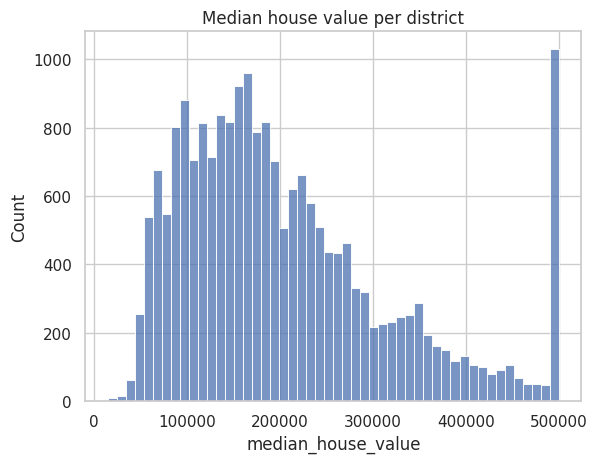

Districts at the $500,001 cap: 965


In [5]:
sns.histplot(housing["median_house_value"], bins=50)
plt.title("Median house value per district")
plt.show()

print("Districts at the $500,001 cap:", (housing["median_house_value"] >= 500001).sum())

🧠 See the tall bar on the far right? Values were **capped at $500,001** when the data was collected. The model can never learn that a district is worth more than that — a real-world data quirk EDA helps you spot.

### 1.2 A map, just from latitude and longitude!

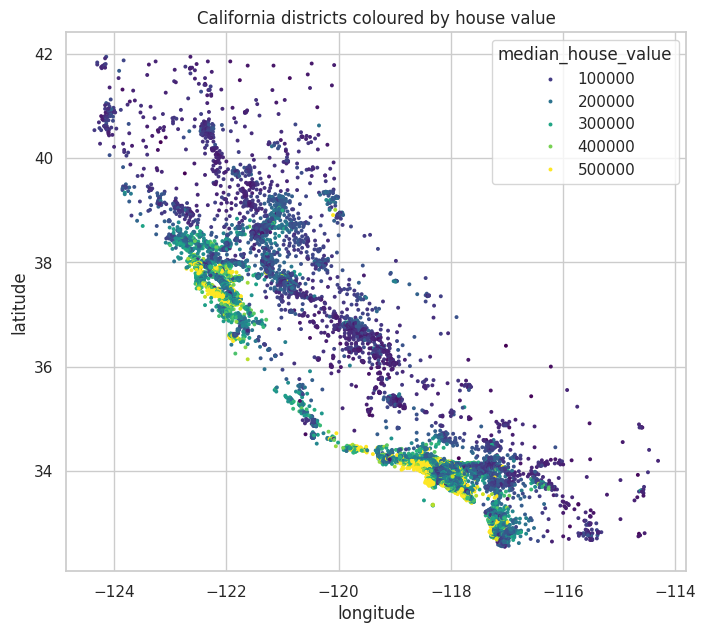

In [12]:
plt.figure(figsize=(8, 7))
sns.scatterplot(data=housing, x="longitude", y="latitude", hue="median_house_value",
                palette="viridis", s=8, linewidth=0)
plt.title("California districts coloured by house value")
plt.show()

🧠 The most expensive districts hug the coast (around San Francisco and Los Angeles). Location clearly matters.

### 1.3 Which features are most related to price?

In [13]:
corr = housing.select_dtypes("number").corr()["median_house_value"].sort_values(ascending=False)
corr.round(2)

,median_house_value
median_house_value,1.00
median_income,0.69
total_rooms,0.13
housing_median_age,0.11
households,0.07
total_bedrooms,0.05
population,-0.02
longitude,-0.05
latitude,-0.14


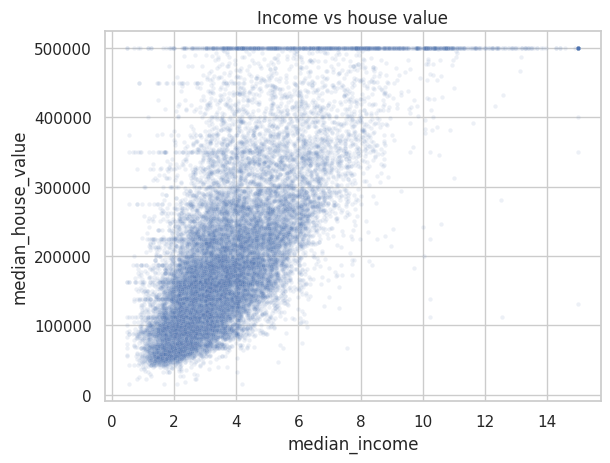

In [14]:
sns.scatterplot(data=housing, x="median_income", y="median_house_value", alpha=0.1, s=10)
plt.title("Income vs house value")
plt.show()

**Median income** is by far the strongest single signal (correlation 0.69).

---
## Part 2 · Cleaning and feature engineering

### 2.1 Missing values
Only `total_bedrooms` has gaps (207 districts). We fill them with the median.

In [15]:
print("Missing before:", housing["total_bedrooms"].isna().sum())
housing["total_bedrooms"] = housing["total_bedrooms"].fillna(housing["total_bedrooms"].median())
print("Missing after:", housing["total_bedrooms"].isna().sum())

Missing before: 0
Missing after: 0


### 2.2 New features: ratios make more sense than totals
A district with 5,000 rooms might just be a big district. **Rooms per household** says more about the houses themselves.

In [16]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

housing.select_dtypes("number").corr()["median_house_value"][
    ["total_rooms", "rooms_per_household", "total_bedrooms", "bedrooms_per_room"]].round(2)

,median_house_value
total_rooms,0.13
rooms_per_household,0.15
total_bedrooms,0.05
bedrooms_per_room,-0.23


🧠 `total_bedrooms` barely relates to price (0.05), but `bedrooms_per_room` does (−0.23): the more of a home's rooms are bedrooms, the cheaper it tends to be.

### 2.3 One-hot encode `ocean_proximity`

In [17]:
housing = pd.get_dummies(housing, columns=["ocean_proximity"], dtype=int)
housing.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'rooms_per_household',
 'bedrooms_per_room',
 'population_per_household',
 'ocean_proximity_<1H OCEAN',
 'ocean_proximity_INLAND',
 'ocean_proximity_ISLAND',
 'ocean_proximity_NEAR BAY',
 'ocean_proximity_NEAR OCEAN']

---
## Part 3 · Split and scale

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = housing.drop(columns="median_house_value")
y = housing["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(X_train)      # fit on TRAIN only
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (16512, 16) | Test: (4128, 16)


We'll use one small helper to print the three regression metrics:
- **MAE** — average size of the error, in dollars
- **RMSE** — like MAE but big errors count extra
- **R²** — share of the variation explained (1 = perfect, 0 = no better than the average)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{name:32s} MAE ${mae:>9,.0f}   RMSE ${rmse:>9,.0f}   R² {r2:.2f}")
    return {"model": name, "MAE": round(mae), "RMSE": round(rmse), "R2": round(r2, 3)}

---
## Part 4 · Models

### 4.1 Baseline: always guess the average price

In [20]:
results = []
baseline_pred = np.full(len(y_test), y_train.mean())
results.append(report("Guess the average", y_test, baseline_pred))

Guess the average                MAE $   90,607   RMSE $  114,486   R² -0.00


### 4.2 Linear regression with one feature: income
The model learns `price = w × income + b`.

In [21]:
from sklearn.linear_model import LinearRegression

lin1 = LinearRegression().fit(X_train[["median_income"]], y_train)
pred1 = lin1.predict(X_test[["median_income"]])
results.append(report("Income only", y_test, pred1))

print(f"\nLearned: price = {lin1.coef_[0]:,.0f} × income + {lin1.intercept_:,.0f}")

Income only                      MAE $   62,991   RMSE $   84,209   R² 0.46

Learned: price = 41,934 × income + 44,460


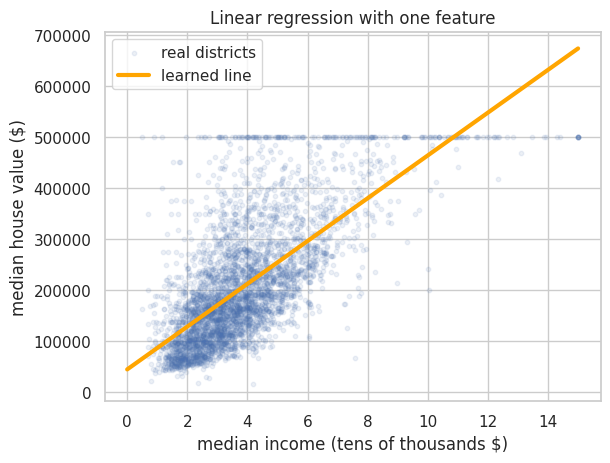

In [22]:
plt.scatter(X_test["median_income"], y_test, alpha=0.1, s=10, label="real districts")
xs = np.linspace(0, 15, 100).reshape(-1, 1)
plt.plot(xs, lin1.predict(pd.DataFrame(xs, columns=["median_income"])), color="orange", linewidth=3, label="learned line")
plt.xlabel("median income (tens of thousands $)")
plt.ylabel("median house value ($)")
plt.legend()
plt.title("Linear regression with one feature")
plt.show()

🧠 Each extra $10,000 of median income adds about $42,000 to the predicted house value. Does the straight line fit the data well everywhere? Look at high incomes and the $500k cap.

### 4.3 Linear regression with all features

In [23]:
lin = LinearRegression().fit(X_train_s, y_train)
pred_all = lin.predict(X_test_s)
results.append(report("Linear regression (all)", y_test, pred_all))

Linear regression (all)          MAE $   50,889   RMSE $   72,669   R² 0.60


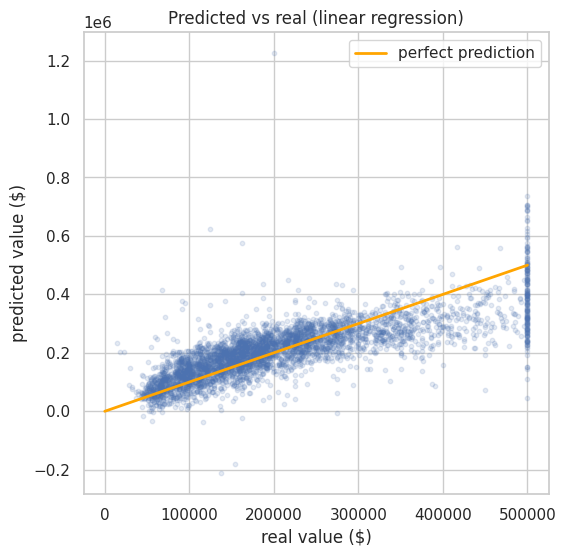

In [24]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_all, alpha=0.15, s=10)
plt.plot([0, 500000], [0, 500000], color="orange", linewidth=2, label="perfect prediction")
plt.xlabel("real value ($)")
plt.ylabel("predicted value ($)")
plt.legend()
plt.title("Predicted vs real (linear regression)")
plt.show()

🧠 Points on the orange line are perfect predictions. Notice the vertical stripe at $500k (the cap), and that the model sometimes predicts **negative** prices — a straight line doesn't know prices can't go below zero!

### 4.4 Which features matter most?

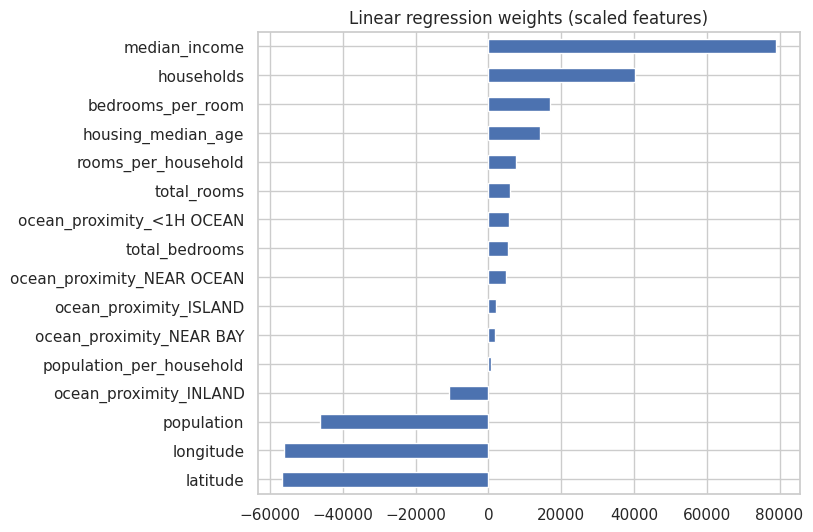

In [25]:
coefs = pd.Series(lin.coef_, index=X.columns).sort_values()
coefs.plot(kind="barh", figsize=(7, 6))
plt.title("Linear regression weights (scaled features)")
plt.show()

### 4.5 Teaser for Day 3: a random forest
A random forest combines many decision trees. It can learn curves and interactions that a straight line can't. Trees don't need scaling, so we use the unscaled data. (This takes ~30 seconds.)

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
results.append(report("Random forest (Day 3 preview)", y_test, rf.predict(X_test)))

Random forest (Day 3 preview)    MAE $   32,338   RMSE $   50,383   R² 0.81


In [27]:
pd.DataFrame(results).set_index("model")

,MAE,RMSE,R2
model,,,
Guess the average,90607,114486,-0.000
Income only,62991,84209,0.459
Linear regression (all),50889,72669,0.597
Random forest (Day 3 preview),32338,50383,0.806


> ✍️ **Exercises**
> 1. Train linear regression on **two** features: `median_income` and `latitude`. Is it better than income alone?
> 2. Train linear regression **without** the three engineered ratio features. How much did feature engineering help?
> 3. Predict the value of a new district using the random forest: copy the first row of `X_test`, change `median_income` to 8.0, and predict.

---
## 🎯 Recap
Baseline → one feature → all features → a smarter model. Each step reduced the error. **Always report MAE/RMSE/R² on the test set and compare with a baseline.**

---
## ✅ Solutions

In [28]:
# Exercise 1
two = ["median_income", "latitude"]
lin2 = LinearRegression().fit(X_train[two], y_train)
report("Income + latitude", y_test, lin2.predict(X_test[two]));

Income + latitude                MAE $   62,519   RMSE $   83,632   R² 0.47


In [29]:
# Exercise 2
ratio_cols = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]
Xtr_no = X_train.drop(columns=ratio_cols); Xte_no = X_test.drop(columns=ratio_cols)
sc_no = StandardScaler().fit(Xtr_no)
lin_no = LinearRegression().fit(sc_no.transform(Xtr_no), y_train)
report("Linear, no engineered features", y_test, lin_no.predict(sc_no.transform(Xte_no)))
report("Linear, with engineered features", y_test, pred_all);
# Surprise! For LINEAR regression the ratio features slightly HURT (R² 0.63 without vs 0.60 with).
# A few districts have extreme ratios (e.g. over 100 rooms per household), and a straight line
# is pulled around by such outliers. Lesson: a feature that looks useful in EDA must still be
# tested on the model - and different models benefit from different features (trees handle them well).
print("Max rooms_per_household:", round(X_train["rooms_per_household"].max(), 1))

Linear, no engineered features   MAE $   50,671   RMSE $   70,061   R² 0.63
Linear, with engineered features MAE $   50,889   RMSE $   72,669   R² 0.60
Max rooms_per_household: 141.9


In [30]:
# Exercise 3
new_district = X_test.iloc[[0]].copy()
print("Original prediction:", f"${rf.predict(new_district)[0]:,.0f}")
new_district["median_income"] = 8.0
print("With income = 8.0:  ", f"${rf.predict(new_district)[0]:,.0f}")

Original prediction: $48,444
With income = 8.0:   $305,441
